# Self-Supervised Learning ile Akciğer X-Ray Analizi (SimCLR)

Bu projede göğüs X-ray görüntüleri üzerinde Self-Supervised Learning (SSL) yaklaşımı uygulanmıştır. Amaç, etiket kullanılmadan güçlü görsel özellikler öğrenmek ve daha sonra bu özellikleri zatürre (pneumonia) sınıflandırmasında kullanmaktır.

## Proje Akışı

1. Veri setinin indirilmesi ve hazırlanması
2. SimCLR veri artırma işlemleri
3. SSL encoder modelinin oluşturulması
4. NT-Xent contrastive loss ile SSL pretraining
5. Linear evaluation ile öğrenilen feature'ların test edilmesi
6. Model tahmin örnekleri ve confidence değerleri
7. Supervised baseline karşılaştırması
8. Confusion matrix ve yanlış tahmin analizi
9. Grad-CAM ile modelin dikkat bölgeleri
10. t-SNE feature visualization
11. ROC ve Precision-Recall eğrileri
12. Genel sonuç ve yorum

## Neden Self-Supervised Learning?

Tıbbi görüntülerde etiketli veri toplamak zor, zaman alıcı ve maliyetlidir. Çünkü görüntülerin doğru etiketlenmesi genellikle uzman bilgisi gerektirir. Self-Supervised Learning yöntemleri, etiket kullanmadan görüntülerden anlamlı temsil (feature representation) öğrenmeyi amaçlar.

Bu projede SimCLR yaklaşımı kullanılarak modelin önce etiketsiz şekilde görsel feature öğrenmesi, daha sonra bu feature'ların sınıflandırma için kullanılması hedeflenmiştir.

## 0. Kaggle Kurulumu

In [ ]:
# Kaggle API token yöntemi

!mkdir -p ~/.kaggle
!echo "KGAT_fe73732c51ade05b02654a2b0721ddc6" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

## 1. Veri Setinin İndirilmesi ve Çıkartılması

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:53<00:00, 21.6MB/s]



## 2. Veri Seti Klasörlerinin Kontrolü

In [ ]:
import os

base_path = "data/chest_xray"

print(os.listdir(base_path))
print("Train:", os.listdir(base_path + "/train"))
print("Test:", os.listdir(base_path + "/test"))
print("Val:", os.listdir(base_path + "/val"))

['__MACOSX', 'chest_xray', 'train', 'val', 'test']
Train: ['PNEUMONIA', 'NORMAL']
Test: ['PNEUMONIA', 'NORMAL']
Val: ['PNEUMONIA', 'NORMAL']


## 3. Gerekli Kütüphanelerin Yüklenmesi

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision import models
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

## 4. GPU Kontrolü

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Kullanılan cihaz:", device)
if device == "cuda":
    print("GPU modeli:", torch.cuda.get_device_name(0))

Kullanılan cihaz: cuda
GPU modeli: Tesla T4


## 5. SimCLR Veri Artırma (Data Augmentation)

SSL aşamasında model, aynı görüntünün iki farklı artırılmış versiyonunu alır. Bu iki versiyon pozitif çift olarak kabul edilir. Amaç, modelin aynı görüntüden gelen farklı görünümleri benzer feature uzayında konumlandırmayı öğrenmesidir.

In [ ]:
class SimCLRTransform:
    def __init__(self):
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.RandomResizedCrop(224, scale=(0.7, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)

## 6. SSL Veri Seti ve DataLoader

Önemli: Veri setinde etiketler klasör isimlerinde bulunmaktadır. Ancak SimCLR pretraining aşamasında bu etiketler kullanılmaz. Model yalnızca görüntüler üzerinden öğrenme gerçekleştirir.

In [ ]:
ssl_dataset = ImageFolder(
    root="data/chest_xray/train",
    transform=SimCLRTransform()
)

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print("SSL görüntü sayısı:", len(ssl_dataset))
print("SSL aşamasında bulunan ama kullanılmayan sınıflar:", ssl_dataset.classes)

SSL görüntü sayısı: 5216
SSL aşamasında bulunan ama kullanılmayan sınıflar: ['NORMAL', 'PNEUMONIA']


## 7. SimCLR Modeli

Encoder, görüntülerden anlamlı feature temsilleri öğrenir. Projection head ise bu temsilleri contrastive learning için embedding uzayına dönüştürür.

In [ ]:
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = models.resnet18(weights=None)
        dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z


ssl_model = SimCLR().to(device)
print("SimCLR modeli hazır")

SimCLR modeli hazır


## 8. NT-Xent Contrastive Loss

Bu bölümde SimCLR modelinin öğrenme mekanizmasını sağlayan NT-Xent (Normalized Temperature-scaled Cross Entropy) loss fonksiyonu tanımlanmaktadır. Amaç benzer görüntü çiftlerini birbirine yaklaştırırken farklı görüntüleri uzaklaştırmaktır.

In [ ]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, device=device).bool()
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch_size),
        torch.diag(sim, -batch_size)
    ])

    loss = -positives + torch.logsumexp(sim, dim=1)
    return loss.mean()

## 9. SSL Eğitimi

Bu aşamada model etiket kullanılmadan eğitilir. Loss değerinin azalması, modelin görüntülerden anlamlı feature'lar öğrenmeye başladığını gösterir.

In [ ]:
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=1e-3)

ssl_losses = []
epochs = 5

for epoch in range(epochs):
    ssl_model.train()
    total_loss = 0

    for (x1, x2), _ in ssl_loader:
        x1 = x1.to(device)
        x2 = x2.to(device)

        _, z1 = ssl_model(x1)
        _, z2 = ssl_model(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(ssl_loader)
    ssl_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] SSL Loss: {avg_loss:.4f}")

Epoch [1/5] SSL Loss: 3.1893
Epoch [2/5] SSL Loss: 2.8566
Epoch [3/5] SSL Loss: 2.7319
Epoch [4/5] SSL Loss: 2.6543
Epoch [5/5] SSL Loss: 2.5733


## 10. SSL Kayıp (Loss) Grafiği

Bu grafik, SSL eğitimi sırasında loss değerinin epoch boyunca nasıl değiştiğini göstermektedir.

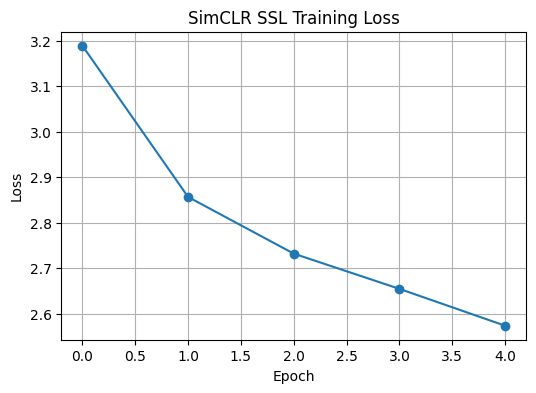

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(ssl_losses, marker="o")
plt.title("SimCLR SSL Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Linear Evaluation

Bu aşamada SSL encoder dondurulmakta ve yalnızca basit bir linear classifier eğitilmektedir. Amaç, SSL encoder tarafından öğrenilen feature'ların ne kadar faydalı olduğunu test etmektir.

## 11. Etiketli Veri Dönüşümleri ve DataLoader Yapısı

In [ ]:
train_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
])

test_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
])

train_dataset = ImageFolder(
    root="data/chest_xray/train",
    transform=train_transform
)

test_dataset = ImageFolder(
    root="data/chest_xray/test",
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

['NORMAL', 'PNEUMONIA']
Train size: 5216
Test size: 624


## 12. Dondurulmuş SSL Encoder Üzerinde Linear Classifier

In [ ]:
class LinearEvaluationModel(nn.Module):
    def __init__(self, encoder, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(512, num_classes)

        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.classifier(h)


linear_model = LinearEvaluationModel(ssl_model.encoder, num_classes=2).to(device)

linear_optimizer = torch.optim.Adam(
    linear_model.classifier.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

linear_losses = []
linear_accs = []
linear_epochs = 5

for epoch in range(linear_epochs):
    linear_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = linear_model(x)
        loss = criterion(outputs, y)

        linear_optimizer.zero_grad()
        loss.backward()
        linear_optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total

    linear_losses.append(avg_loss)
    linear_accs.append(acc)

    print(f"Epoch [{epoch+1}/{linear_epochs}] Linear Loss: {avg_loss:.4f} | Train Acc: {acc:.4f}")

Epoch [1/5] Linear Loss: 0.2699 | Train Acc: 0.8907
Epoch [2/5] Linear Loss: 0.2453 | Train Acc: 0.8999
Epoch [3/5] Linear Loss: 0.2270 | Train Acc: 0.9080
Epoch [4/5] Linear Loss: 0.2288 | Train Acc: 0.9043
Epoch [5/5] Linear Loss: 0.2212 | Train Acc: 0.9101


## 13. SSL Encoder + Linear Classifier Test Sonuçları

SSL + Linear Evaluation test accuracy: 0.875

              precision    recall  f1-score   support

      NORMAL       0.92      0.73      0.81       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



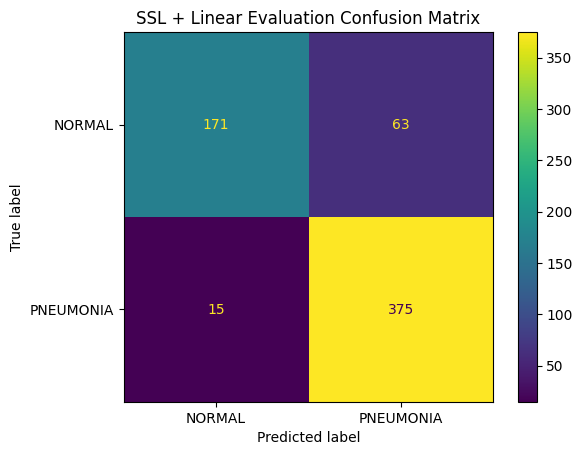

In [ ]:
linear_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = linear_model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

ssl_linear_accuracy = accuracy_score(all_labels, all_preds)

print("SSL + Linear Evaluation test accuracy:", ssl_linear_accuracy)
print()
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot()
plt.title("SSL + Linear Evaluation Confusion Matrix")
plt.show()

375 → pneumonia doğru tahmin (TP)
15 → pneumonia olup kaçırılan vaka (TN)
171 → normal doğru tahmin (FP)
63 → normal olup pneumonia sanılan vaka (FN)

Model yaklaşık %87.5 test accuracy elde etti. Özellikle pneumonia sınıfında recall değeri %96 olduğu için model zatürre vakalarının büyük kısmını doğru yakalayabildi.

Tıbbi görüntüleme problemlerinde false negative yani hasta kişiyi sağlıklı tahmin etmek risklidir. Bu yüzden pneumonia sınıfındaki yüksek recall önemli bir avantajdır.

## 14. Model Tahmin Örnekleri

Bu bölümde eğitilen SSL + Linear Evaluation modelinin test veri setinden seçilen örnek görüntüler üzerindeki tahminleri gösterilmektedir. Her görüntü için gerçek sınıf ve modelin tahmin ettiği sınıf birlikte verilmiştir.

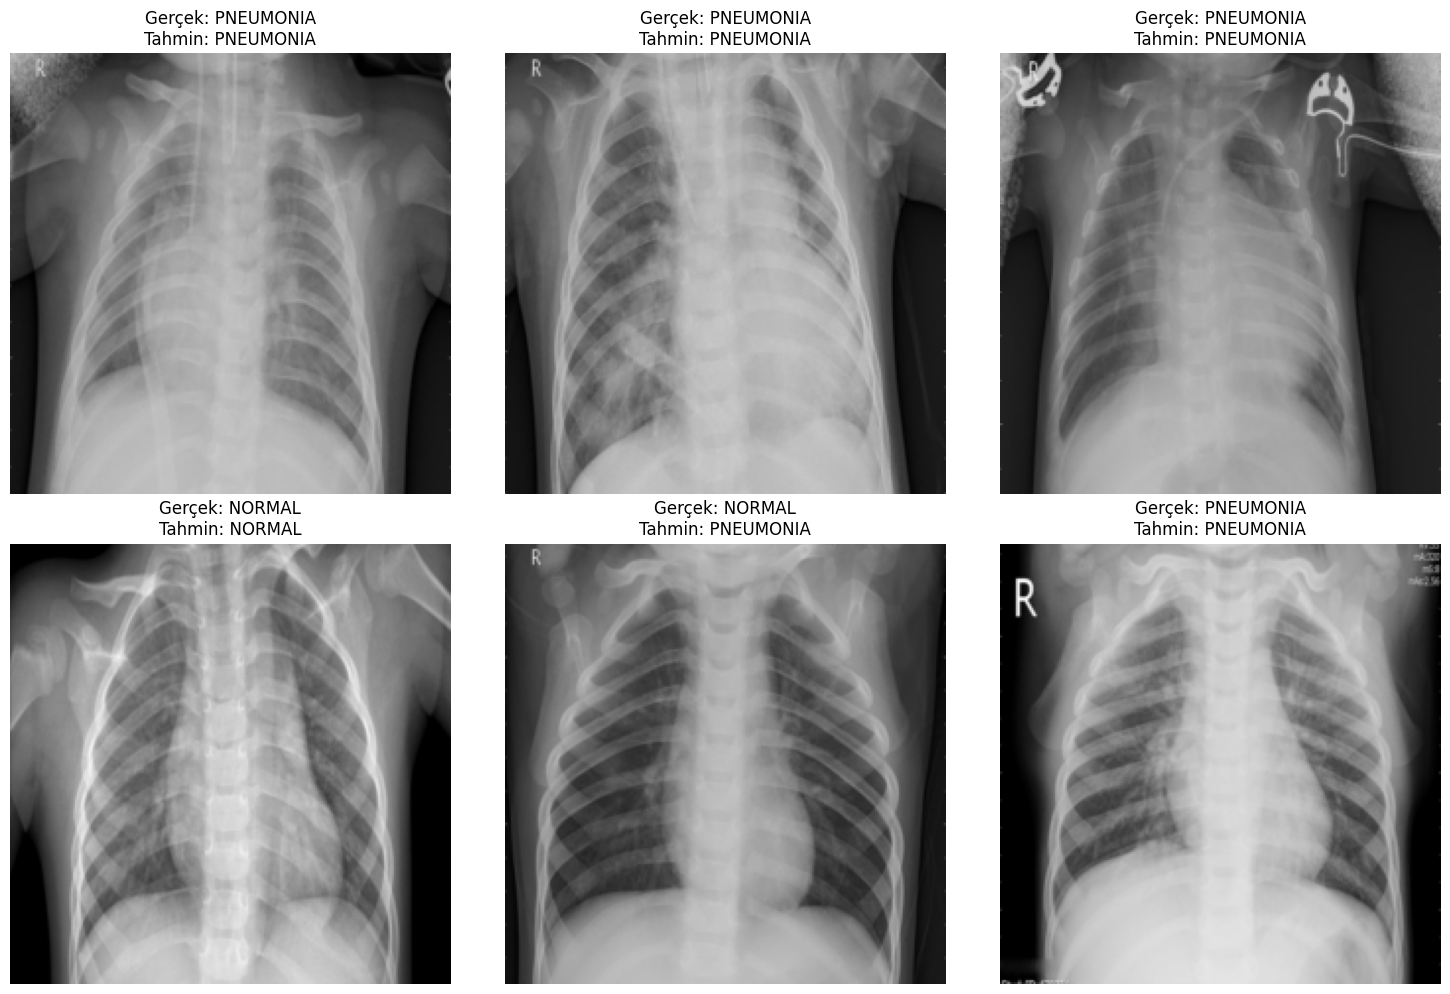

In [ ]:
import random

linear_model.eval()

indices = random.sample(range(len(test_dataset)), 6)

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = linear_model(x)
        pred = output.argmax(dim=1).item()

    true_label = test_dataset.classes[label]
    pred_label = test_dataset.classes[pred]

    img_np = img.permute(1,2,0).numpy()

    plt.subplot(2,3,i+1)
    plt.imshow(img_np, cmap="gray")
    plt.title(f"Gerçek: {true_label}\nTahmin: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 15. Confidence Değeri ile Model Tahminleri

Bu bölümde modelin test görüntüleri üzerindeki tahminleri ve bu tahminlere ait confidence değerleri gösterilmektedir. Confidence değeri, modelin yaptığı tahminden ne kadar emin olduğunu ifade eder.

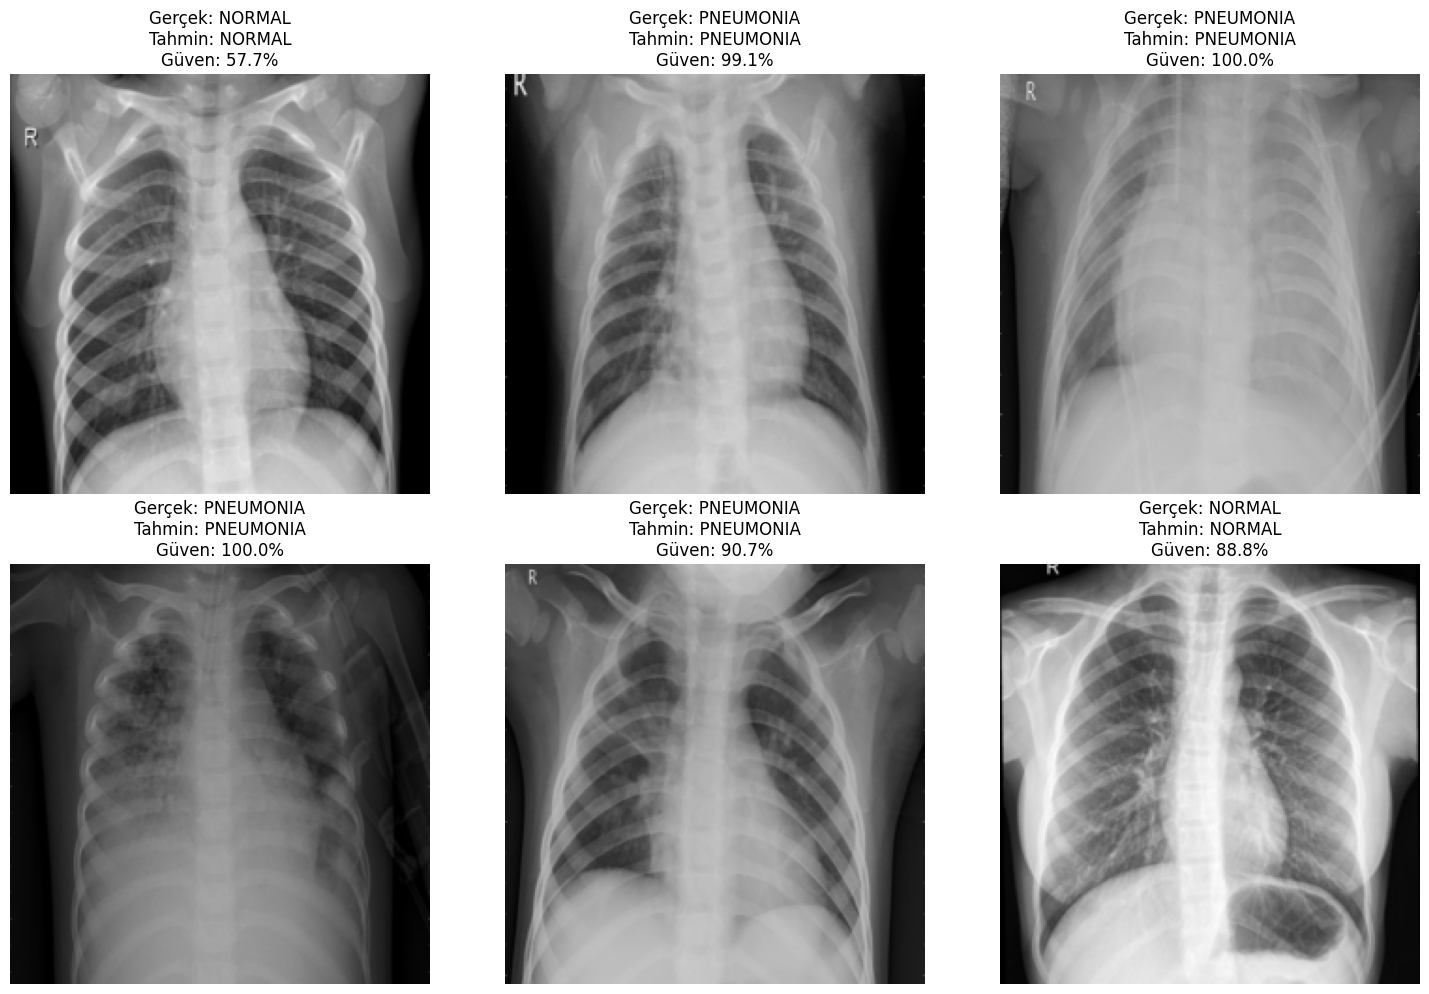

In [ ]:
import random
import torch.nn.functional as F

linear_model.eval()

indices = random.sample(range(len(test_dataset)), 6)

plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = linear_model(x)
        probs = F.softmax(output, dim=1)
        pred = probs.argmax(dim=1).item()
        confidence = probs[0, pred].item() * 100

    true_label = test_dataset.classes[label]
    pred_label = test_dataset.classes[pred]

    img_np = img.permute(1,2,0).numpy()

    plt.subplot(2,3,i+1)
    plt.imshow(img_np, cmap="gray")
    plt.title(f"Gerçek: {true_label}\nTahmin: {pred_label}\nGüven: {confidence:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Yanlış Tahmin Edilen Görüntülerin Analizi

Bu bölümde modelin yanlış sınıflandırdığı test görüntüleri gösterilmektedir. Bu analiz, modelin hangi tür görüntülerde zorlandığını anlamak ve modelin limitlerini değerlendirmek için kullanılır.

In [ ]:
wrong_indices = []

linear_model.eval()

with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, label = test_dataset[idx]
        x = img.unsqueeze(0).to(device)

        output = linear_model(x)
        pred = output.argmax(dim=1).item()

        if pred != label:
            wrong_indices.append(idx)

print("Yanlış tahmin sayısı:", len(wrong_indices))

Yanlış tahmin sayısı: 78


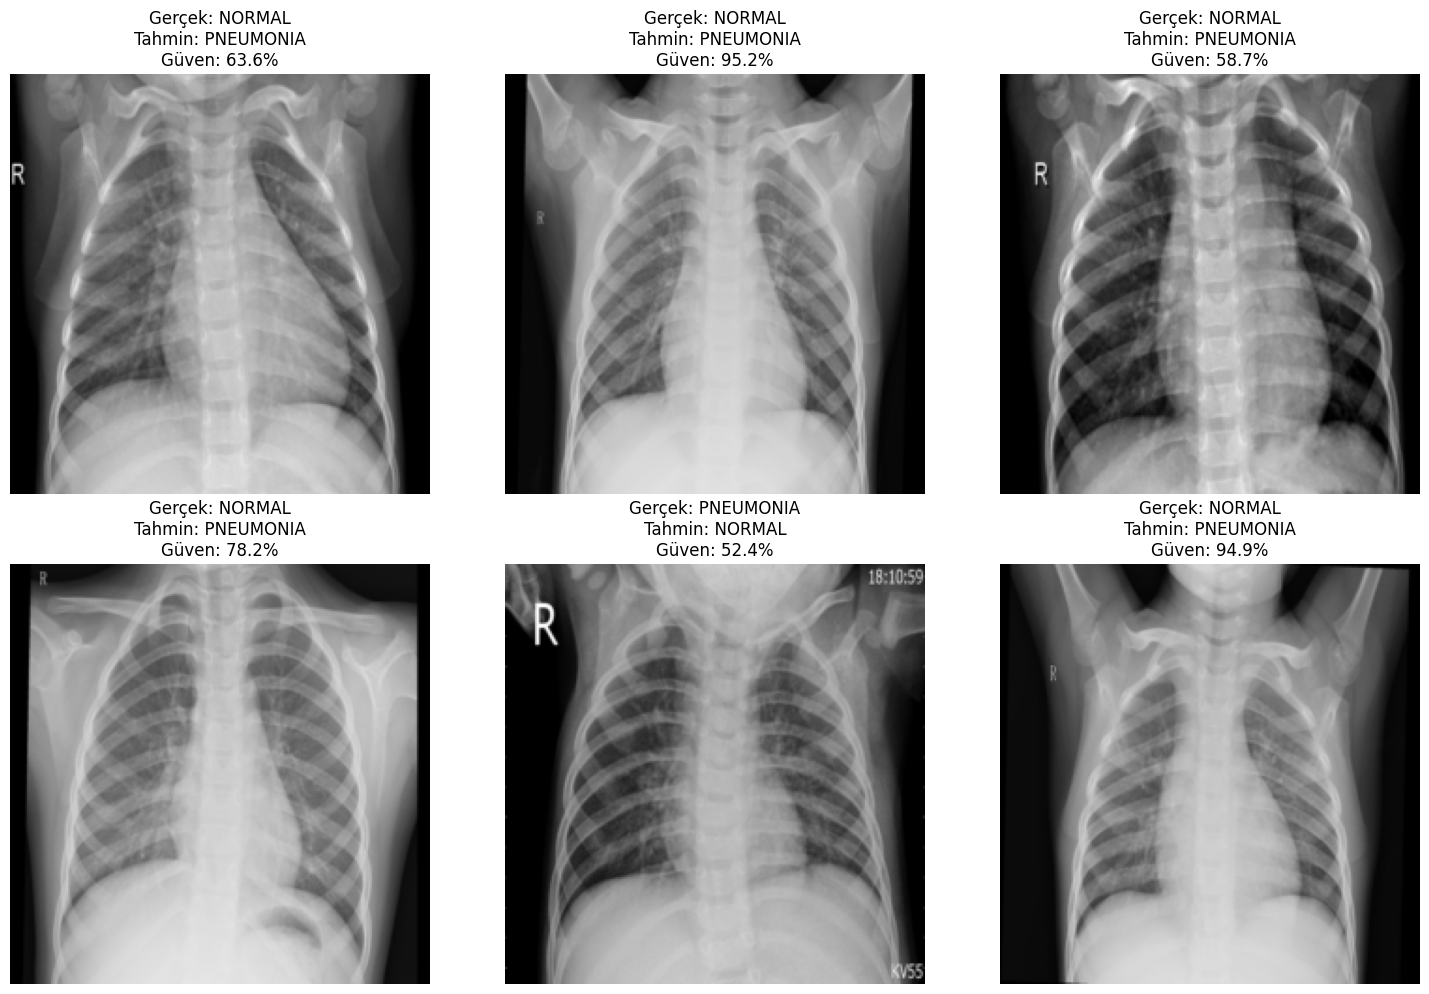

In [ ]:
import random
import torch.nn.functional as F

sample_wrong = random.sample(wrong_indices, min(6, len(wrong_indices)))

plt.figure(figsize=(15,10))

for i, idx in enumerate(sample_wrong):
    img, label = test_dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = linear_model(x)
        probs = F.softmax(output, dim=1)
        pred = probs.argmax(dim=1).item()
        conf = probs[0, pred].item() * 100

    true_label = test_dataset.classes[label]
    pred_label = test_dataset.classes[pred]

    plt.subplot(2,3,i+1)
    plt.imshow(img.permute(1,2,0).numpy(), cmap="gray")
    plt.title(f"Gerçek: {true_label}\nTahmin: {pred_label}\nGüven: {conf:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Supervised Baseline

Bu bölümde klasik supervised learning yaklaşımı kullanılmaktadır. Model, eğitim sürecinin başından itibaren görüntü etiketlerini kullanarak öğrenme gerçekleştirmektedir.

## 17. Denetimli Öğrenme (Supervised) Modeli

In [ ]:
class SupervisedCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


supervised_model = SupervisedCNN(num_classes=2).to(device)

sup_optimizer = torch.optim.Adam(
    supervised_model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

sup_losses = []
sup_accs = []
sup_epochs = 5

for epoch in range(sup_epochs):
    supervised_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = supervised_model(x)
        loss = criterion(outputs, y)

        sup_optimizer.zero_grad()
        loss.backward()
        sup_optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total

    sup_losses.append(avg_loss)
    sup_accs.append(acc)

    print(f"Epoch [{epoch+1}/{sup_epochs}] Supervised Loss: {avg_loss:.4f} | Train Acc: {acc:.4f}")

Epoch [1/5] Supervised Loss: 0.2142 | Train Acc: 0.9160
Epoch [2/5] Supervised Loss: 0.1302 | Train Acc: 0.9525
Epoch [3/5] Supervised Loss: 0.1066 | Train Acc: 0.9611
Epoch [4/5] Supervised Loss: 0.0962 | Train Acc: 0.9653
Epoch [5/5] Supervised Loss: 0.0806 | Train Acc: 0.9714


## 18. Supervised Baseline Test Sonuçları

Supervised Test Accuracy: 0.844551282051282
              precision    recall  f1-score   support

      NORMAL       0.95      0.62      0.75       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.84       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.84      0.84       624



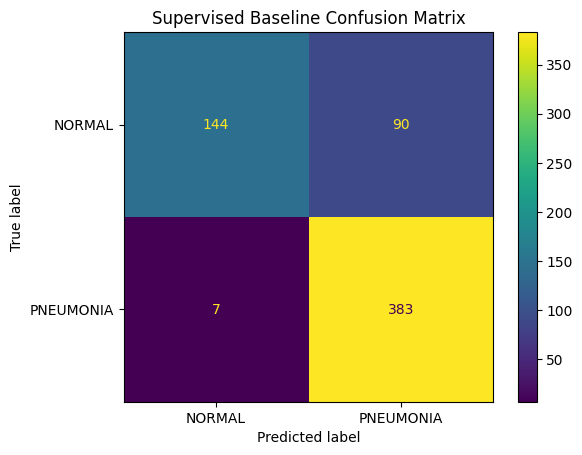

In [ ]:
supervised_model.eval()
all_preds_sup = []
all_labels_sup = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = supervised_model(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds_sup.extend(preds)
        all_labels_sup.extend(y.numpy())

supervised_accuracy = accuracy_score(all_labels_sup, all_preds_sup)
print("Supervised Test Accuracy:", supervised_accuracy)
print(classification_report(all_labels_sup, all_preds_sup, target_names=test_dataset.classes))

cm_sup = confusion_matrix(all_labels_sup, all_preds_sup)
disp_sup = ConfusionMatrixDisplay(confusion_matrix=cm_sup, display_labels=test_dataset.classes)
disp_sup.plot()
plt.title("Supervised Baseline Confusion Matrix")
plt.show()

# Karşılaştırma Sonuçları

## 19. SSL ve Supervised Accuracy Karşılaştırması

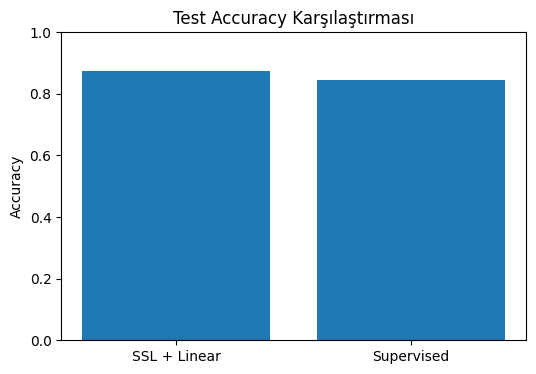

SSL + Linear accuracy: 0.875
Supervised accuracy: 0.844551282051282


In [ ]:
methods = ["SSL + Linear", "Supervised"]
accuracies = [ssl_linear_accuracy, supervised_accuracy]

plt.figure(figsize=(6,4))
plt.bar(methods, accuracies)
plt.ylim(0, 1)
plt.title("Test Accuracy Karşılaştırması")
plt.ylabel("Accuracy")
plt.show()

print("SSL + Linear accuracy:", ssl_linear_accuracy)
print("Supervised accuracy:", supervised_accuracy)

## 20. Eğitim Loss Eğrileri

Bu grafik SSL pretraining, linear evaluation ve supervised baseline eğitim süreçlerinde loss değerlerinin nasıl değiştiğini göstermektedir.

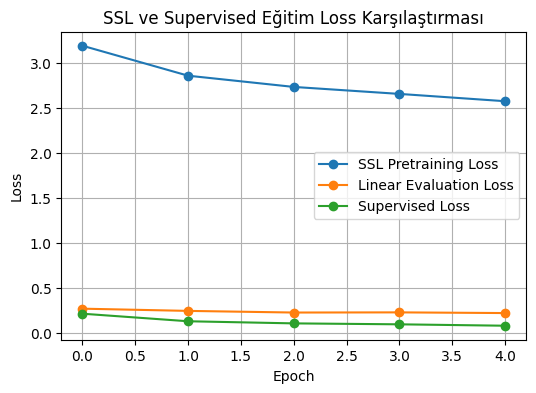

In [ ]:
# Eğer notebook yeniden açıldığında ssl_losses değişkeni kaybolursa,
# önce SSL eğitim hücresini tekrar çalıştır. Aşağıdaki liste örnek çalıştırmadan alınan değerlerdir.

if "ssl_losses" not in globals():
    ssl_losses = [3.1937, 2.8641, 2.7343, 2.6557, 2.5786]

plt.figure(figsize=(6,4))

plt.plot(ssl_losses, marker="o", label="SSL Pretraining Loss")
plt.plot(linear_losses, marker="o", label="Linear Evaluation Loss")
plt.plot(sup_losses, marker="o", label="Supervised Loss")

plt.title("SSL ve Supervised Eğitim Loss Karşılaştırması")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 21. Grad-CAM ile Modelin Dikkat Bölgelerinin Görselleştirilmesi

Bu bölümde Grad-CAM yöntemi kullanılarak modelin karar verirken görüntünün hangi bölgelerine odaklandığı görselleştirilmektedir. Isı haritasındaki yoğun bölgeler modelin tahmin sırasında daha fazla dikkat ettiği alanları göstermektedir.

In [ ]:
import cv2
import matplotlib.cm as cm

In [ ]:
target_layer = supervised_model.model.layer4[-1]

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

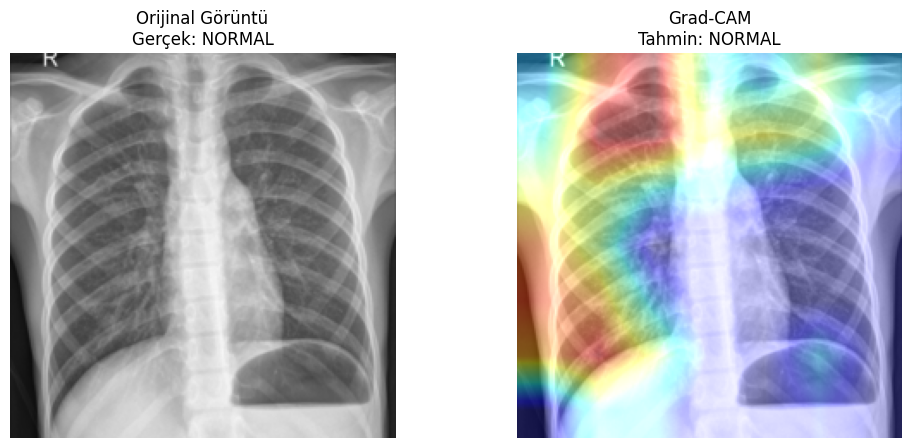

In [ ]:
import random

supervised_model.eval()

# Aynı hücre birkaç kez çalıştırılırsa eski aktivasyonların karışmaması için temizlenir.
activations.clear()
gradients.clear()

idx = random.randint(0, len(test_dataset)-1)
img, label = test_dataset[idx]
x = img.unsqueeze(0).to(device)

output = supervised_model(x)
pred = output.argmax(dim=1).item()

supervised_model.zero_grad()
output[0, pred].backward()

grads = gradients[0]
acts = activations[0]

pooled_grads = torch.mean(grads, dim=[0,2,3])

for i in range(acts.shape[1]):
    acts[:, i, :, :] *= pooled_grads[i]

heatmap = acts.mean(dim=1).squeeze().detach().cpu().numpy()
heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / (heatmap.max() + 1e-8)

img_np = img.permute(1,2,0).numpy()
heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
heatmap_color = cm.jet(heatmap)[:, :, :3]

superimposed = heatmap_color * 0.4 + img_np
superimposed = np.clip(superimposed, 0, 1)

true_label = test_dataset.classes[label]
pred_label = test_dataset.classes[pred]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_np, cmap="gray")
plt.title(f"Orijinal Görüntü\nGerçek: {true_label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(superimposed)
plt.title(f"Grad-CAM\nTahmin: {pred_label}")
plt.axis("off")

plt.show()

## 22. t-SNE Feature Görselleştirmesi

Bu bölümde SSL encoder tarafından öğrenilen yüksek boyutlu feature'lar 2 boyutlu uzaya indirgenerek görselleştirilir. Amaç NORMAL ve PNEUMONIA örneklerinin feature uzayında nasıl dağıldığını incelemektir.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

linear_model.eval()

features = []
labels = []

max_samples = 500

with torch.no_grad():
    count = 0

    for x, y in test_loader:
        x = x.to(device)

        h = linear_model.encoder(x)

        features.append(h.cpu().numpy())
        labels.append(y.numpy())

        count += x.size(0)

        if count >= max_samples:
            break

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

features = features[:max_samples]
labels = labels[:max_samples]

print("Feature boyutu:", features.shape)
print("Etiket boyutu:", labels.shape)

Feature boyutu: (500, 512)
Etiket boyutu: (500,)


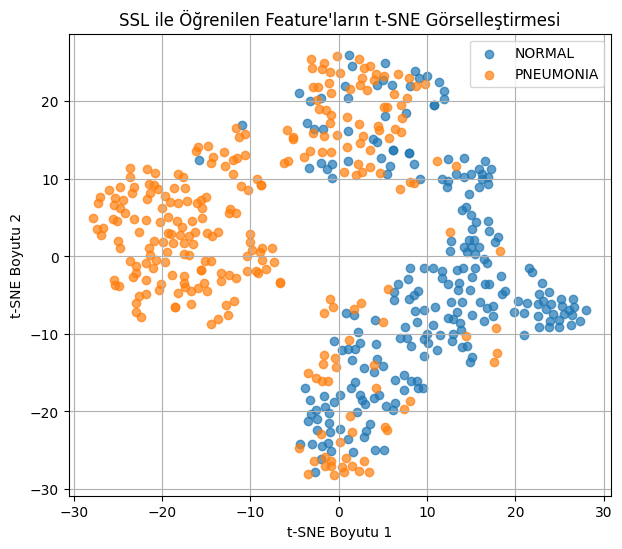

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

features_2d = tsne.fit_transform(features)

plt.figure(figsize=(7,6))

for class_idx, class_name in enumerate(test_dataset.classes):
    idxs = labels == class_idx
    plt.scatter(
        features_2d[idxs, 0],
        features_2d[idxs, 1],
        label=class_name,
        alpha=0.7
    )

plt.title("SSL ile Öğrenilen Feature'ların t-SNE Görselleştirmesi")
plt.xlabel("t-SNE Boyutu 1")
plt.ylabel("t-SNE Boyutu 2")
plt.legend()
plt.grid(True)
plt.show()

## 23. ROC ve Precision-Recall Eğrileri

ROC-AUC ve Average Precision skorları modelin sınıfları ayırma performansını daha detaylı analiz etmek için kullanılır. Özellikle dengesiz veri setlerinde Precision-Recall eğrisi önemli bir değerlendirme aracıdır.

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

In [ ]:
linear_model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = linear_model(x)

        probs = torch.softmax(outputs, dim=1)[:,1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

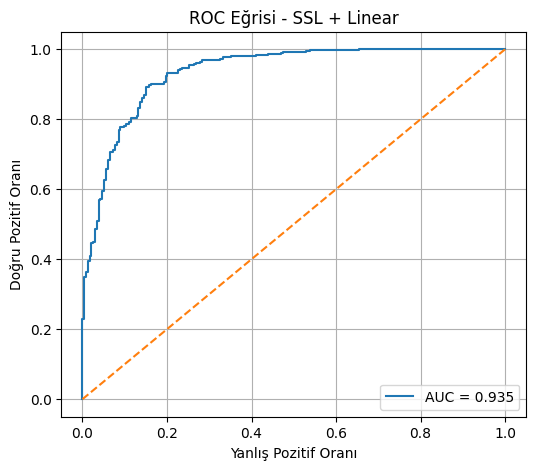

ROC-AUC değeri: 0.9345277229892615


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Yanlış Pozitif Oranı")
plt.ylabel("Doğru Pozitif Oranı")
plt.title("ROC Eğrisi - SSL + Linear")
plt.legend()
plt.grid(True)

plt.show()

print("ROC-AUC değeri:", roc_auc)

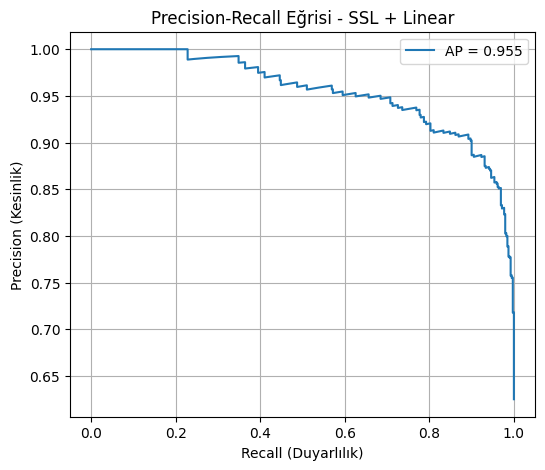

Average Precision değeri: 0.9547794322277536


In [ ]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

ap_score = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")

plt.xlabel("Recall (Duyarlılık)")
plt.ylabel("Precision (Kesinlik)")

plt.title("Precision-Recall Eğrisi - SSL + Linear")
plt.legend()
plt.grid(True)

plt.show()

print("Average Precision değeri:", ap_score)

# Genel Sonuç

Bu projede SimCLR tabanlı Self-Supervised Learning yaklaşımı ile göğüs X-ray görüntülerinden anlamlı feature'lar öğrenilmiştir.

## Ana Bulgular

- SimCLR pretraining aşamasında model etiket kullanmadan görüntülerden feature öğrenmiştir.
- Linear evaluation sonucunda SSL encoder'ın sınıflandırma için kullanılabilir temsiller öğrendiği görülmüştür.
- Supervised baseline ile karşılaştırma yapılarak SSL yaklaşımının genelleme performansı analiz edilmiştir.
- Confusion matrix, yanlış tahmin analizi, Grad-CAM ve t-SNE ile modelin davranışı daha detaylı incelenmiştir.
- ROC-AUC ve Precision-Recall sonuçları modelin sınıflar arasındaki ayırma gücünü değerlendirmek için kullanılmıştır.



Sonuçlar, SSL yaklaşımının tıbbi görüntülerde etiket kullanılmadan da anlamlı görsel temsiller öğrenebildiğini göstermektedir. Bu nedenle SSL, özellikle etiketli verinin sınırlı olduğu tıbbi görüntüleme problemlerinde önemli bir yöntemdir.